<a href="https://colab.research.google.com/github/negilbabu/Heart-Disease-Prediction-Ai-/blob/dev/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update
!apt-get install git

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

# About the Dataset

In [12]:
from tabulate import tabulate

data = [
    ["age", "Age of the patient in years"],
    ["sex", "Gender of the patient (0 = male, 1 = female)"],
    ["cp", "Chest pain type: 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic"],
    ["trestbps", "Resting blood pressure in mmHg"],
    ["chol", "Serum cholesterol in mg/dl"],
    ["fbs", "Fasting blood sugar level, categorized as above 120 mg/dl (1 = true, 0 = false)"],
    ["restecg", "Resting ECG results: 0: Normal, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy"],
    ["thalach", "Maximum heart rate achieved during a stress test"],
    ["exang", "Exercise-induced angina (1 = yes, 0 = no)"],
    ["oldpeak", "ST depression induced by exercise relative to rest"],
    ["slope", "Slope of peak exercise ST segment: 0: Upsloping, 1: Flat, 2: Downsloping"],
    ["ca", "Number of major vessels (0-4) colored by fluoroscopy"],
    ["thal", "Thallium stress test result: 0: Normal, 1: Fixed defect, 2: Reversible defect, 3: Not described"],
    ["target", "Heart disease status (0 = no disease, 1 = presence of disease)"]
]

print(tabulate(data, headers=["Feature", "Description"], tablefmt="grid"))


+-----------+-------------------------------------------------------------------------------------------------+
| Feature   | Description                                                                                     |
+===========+=================================================================================================+
| age       | Age of the patient in years                                                                     |
+-----------+-------------------------------------------------------------------------------------------------+
| sex       | Gender of the patient (0 = male, 1 = female)                                                    |
+-----------+-------------------------------------------------------------------------------------------------+
| cp        | Chest pain type: 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic    |
+-----------+-------------------------------------------------------------------------------------------

# Importing necessory Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix , ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Data Exploration

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/abdelDebug/Heart-Disease-Data/refs/heads/main/heart_disease.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [16]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [17]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [18]:
df.shape

(303, 14)

In [19]:
df["target"].unique()

array([0, 1])

# Data Preprocessing

In [4]:
df.columns = df.columns.str.strip()

In [21]:
print("Checking for null values....")
count = df.isnull().sum()
for col, null_count in count.items():
    if null_count > 0:
        print(f"Column '{col}' has {null_count} null values. Removing null values...")
        df = df.dropna(subset=[col])

    else:
        print(f"Column '{col}' has no null values.")
print("Shape of dataframe", df.shape)

Checking for null values....
Column 'age' has no null values.
Column 'sex' has no null values.
Column 'cp' has no null values.
Column 'trestbps' has no null values.
Column 'chol' has no null values.
Column 'fbs' has no null values.
Column 'restecg' has no null values.
Column 'thalach' has no null values.
Column 'exang' has no null values.
Column 'oldpeak' has no null values.
Column 'slope' has no null values.
Column 'ca' has no null values.
Column 'thal' has no null values.
Column 'target' has no null values.
Shape of dataframe (303, 14)


In [22]:
print("Checking for duplicated rows:")
duplicated_rows = df.duplicated()
print(f"Total duplicated rows: {duplicated_rows.sum()}")

if duplicated_rows.any():
    df_removed_duplicates = df.drop_duplicates()
    print("Shape of dataframe after removing duplicates", df_removed_duplicates.shape)

Checking for duplicated rows:
Total duplicated rows: 0


# **Outlier Analysis**
For numeric features

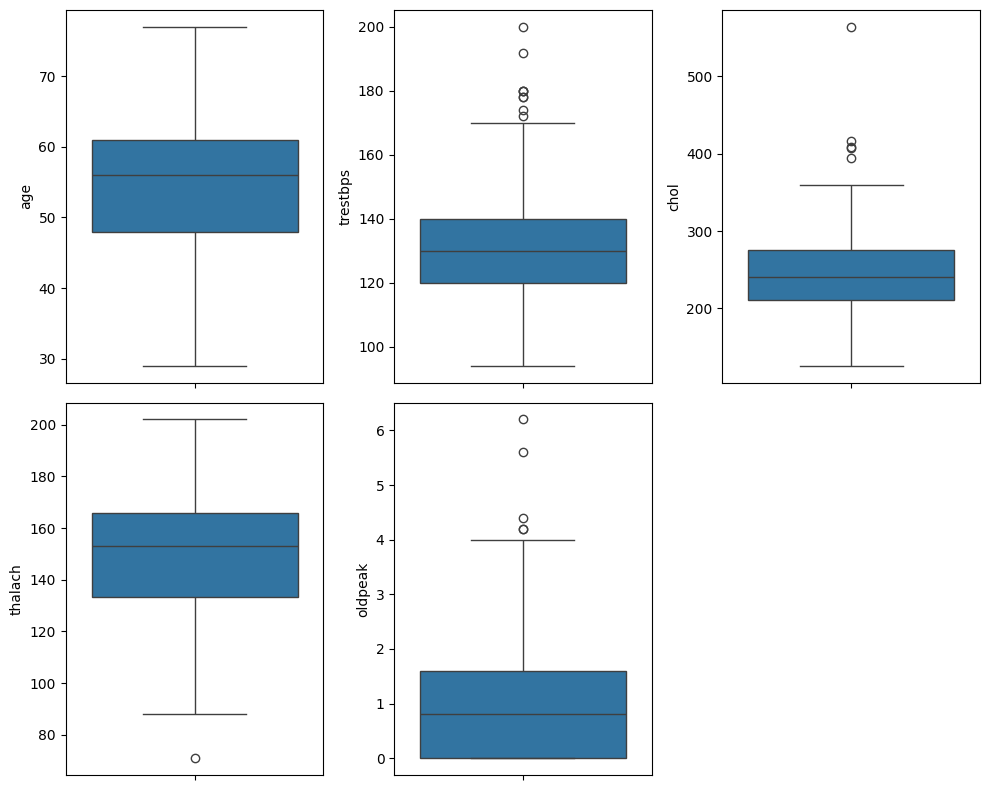

In [5]:
fig, axs = plt.subplots(2,3, figsize = (10,8))
plt1 = sns.boxplot(df['age'], ax = axs[0,0])
plt2 = sns.boxplot(df['trestbps'], ax = axs[0,1])
plt3 = sns.boxplot(df['chol'], ax = axs[0,2])
plt1 = sns.boxplot(df['thalach'], ax = axs[1,0])
plt2 = sns.boxplot(df['oldpeak'], ax = axs[1,1])

fig.delaxes(axs[1, 2])

plt.tight_layout()

Outliers are present for trestbps, chol, thalach and oldpeak. Among these trestbps and chol. We have to handle the outliers before further steps.

Treating Outliers for trestbps

In [58]:
# Calculate IQR and filter out outliers
Q1 = df.trestbps.quantile(0.25)
Q3 = df.trestbps.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['trestbps'] > max_limit].shape[0]

total_data_points = df.shape[0]
percentage_outliers = (outlier_count / total_data_points) * 100
print(f"Percentage of outliers in 'trestbps': {percentage_outliers:.2f}%")

IQR: 20.0
Min Limit: 90.0
Max Limit: 170.0
Percentage of outliers in 'trestbps': 2.97%


In [25]:
df.loc[df['trestbps'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
14,52,1,2,172,199,1,0,162,0,0.5,0,0,3,0
83,68,1,2,180,274,1,2,150,1,1.6,1,0,3,1
126,56,0,3,200,288,1,2,133,1,4.0,2,2,3,1
172,59,0,3,174,249,0,0,143,1,0.0,1,0,1,1
183,59,1,0,178,270,0,2,145,0,4.2,2,0,3,0
188,54,1,1,192,283,0,2,195,0,0.0,0,1,3,1
201,64,0,3,180,325,0,0,154,1,0.0,0,0,1,0
213,66,0,3,178,228,1,0,165,1,1.0,1,2,3,1
231,55,0,3,180,327,0,1,117,1,3.4,1,0,1,1


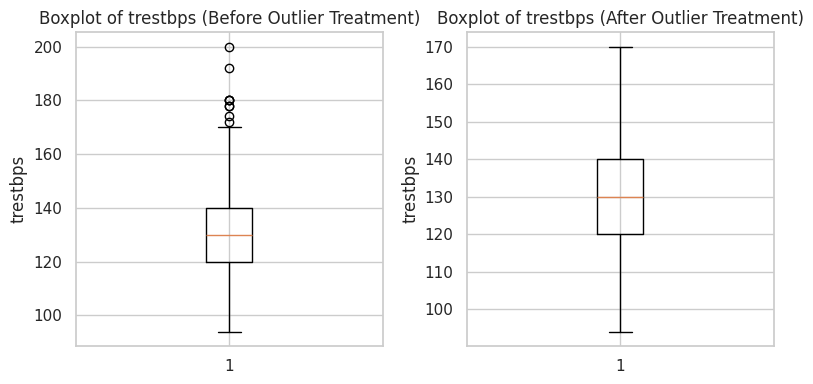

In [59]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on trestbps
plt.subplot(1, 2, 1)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (Before Outlier Treatment)")
plt.ylabel("trestbps")


# Imputation of outlier
df.loc[df['trestbps'] > max_limit ,'trestbps']=np.median(df['trestbps'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.trestbps)
plt.title("Boxplot of trestbps (After Outlier Treatment)")
plt.ylabel("trestbps")

# Adjust layout and display
plt.tight_layout()
plt.show()

We have decided to treat the outlier using imputation because we only have 303 data and removing a significant data from dataset may affect the model.
After imputation, no outlier is present in trestbps

In [60]:
count_outliers = df.loc[df['trestbps'] > max_limit].shape[0]
print(f"Number of rows with 'trestbps' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'trestbps' greater than 170.0(max limit) =  0


Treating outliers for Chol

In [61]:
# Calculate IQR and filter out outliers
Q1 = df.chol.quantile(0.25)
Q3 = df.chol.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['chol'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'chol': {percentage_outliers:.2f}%")

IQR: 64.0
Min Limit: 115.0
Max Limit: 371.0
Percentage of outliers in 'chol': 1.65%


In [29]:
df.loc[df['chol'] > max_limit]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
48,65,0,2,140,417,1,2,157,0,0.8,0,1,1,0
121,63,0,3,150,407,0,2,154,0,4.0,1,3,3,1
152,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
173,62,0,3,140,394,0,2,157,0,1.2,1,0,1,0
181,56,0,3,134,409,0,2,150,1,1.9,1,2,3,1


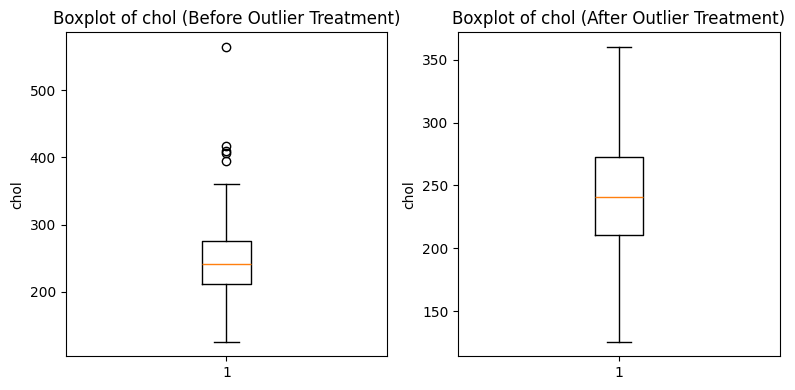

In [30]:
plt.figure(figsize=(8, 4))
# Plot boxplot before outlier treatment on chol
plt.subplot(1, 2, 1)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (Before Outlier Treatment)")
plt.ylabel("chol")


# Imputation of outlier
df.loc[df['chol'] > max_limit ,'chol']=np.median(df['chol'])

# Plot boxplot after outlier treatment on trestbps
plt.subplot(1, 2, 2)
plt.boxplot(df.chol)
plt.title("Boxplot of chol (After Outlier Treatment)")
plt.ylabel("chol")

# Adjust layout and display
plt.tight_layout()
plt.show()

Like we did on trestbps, here also implimented the imputation for handling the outliers in chol. After imputation there is no outlier in chol.

In [31]:
count_outliers = df.loc[df['chol'] > max_limit].shape[0]
print(f"Number of rows with 'chol' greater than {max_limit}(max limit) =  {count_outliers}")

Number of rows with 'chol' greater than 371.0(max limit) =  0


In [38]:
# Calculate IQR and filter out outliers
Q1 = df.thalach.quantile(0.25)
Q3 = df.thalach.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['thalach'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'thalach': {percentage_outliers:.2f}%")

IQR: 32.5
Min Limit: 84.75
Max Limit: 214.75
Percentage of outliers in 'thalach': 0.00%


In [64]:
# Calculate IQR and filter out outliers
Q1 = df.oldpeak.quantile(0.25)
Q3 = df.oldpeak.quantile(0.75)
IQR = Q3 - Q1
min_limit = Q1 - 1.5*IQR
max_limit = Q3 + 1.5*IQR
print("IQR:", IQR)
print("Min Limit:", min_limit)
print("Max Limit:", max_limit)

# Count the number of outliers
outlier_count = df.loc[df['oldpeak'] > max_limit].shape[0]

# Calculate the total number of data points
total_data_points = df.shape[0]

# Calculate the percentage of outliers
percentage_outliers = (outlier_count / total_data_points) * 100

# Print the percentage of outliers
print(f"Percentage of outliers in 'oldpeak': {percentage_outliers:.2f}%")

IQR: 1.6
Min Limit: -2.4000000000000004
Max Limit: 4.0
Percentage of outliers in 'oldpeak': 1.65%


In [65]:
df.loc[df['oldpeak'] > max_limit]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
91,62,0,3,160,164,0,2,145,0,6.2,2,3,3,1
123,55,1,3,140,217,0,0,111,1,5.6,2,0,3,1
183,59,1,0,130,270,0,2,145,0,4.2,2,0,3,0
191,51,1,3,140,298,0,0,122,1,4.2,1,3,3,1
285,58,1,3,114,318,0,1,140,0,4.4,2,3,2,1


Here only 5 attributes has values greater than maximum limit. But when we analyze the medical data, for a person having multiple blockages for heart vessels, it is possible to have such extreme values. By considering that we can ignore oldpeak outliers here.

# EDA and Data visualization

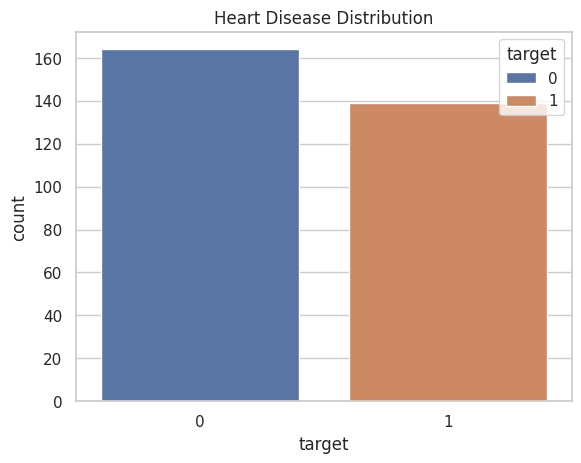

In [10]:
sns.set(style="whitegrid")

sns.countplot(x='target',hue='target', data=df)
plt.title('Heart Disease Distribution')

plt.show()

Heart disease distribution is almost equally distributed.
People with heart disease are less than those without heart disease

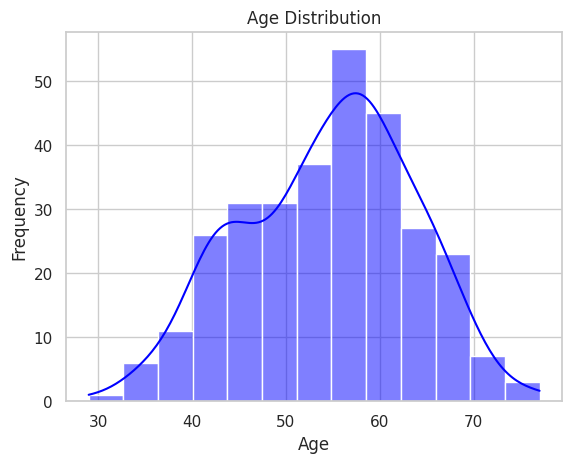

In [11]:
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Age is also almost equally distributed among the dataset but a littlebit right skewed.

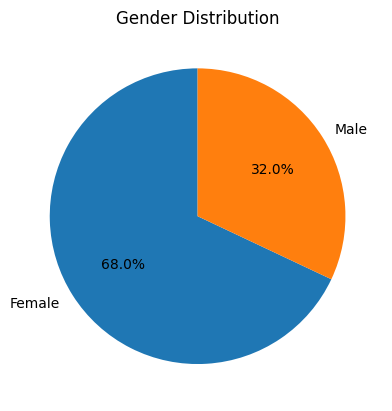

In [7]:
# Mapping gender values to labels
gender_mapping = {0: 'Male', 1: 'Female'}
df_mapped = df.copy()
df_mapped['Gender'] = df_mapped['sex'].map(gender_mapping)

gender_counts = df_mapped['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

Pie chart shows that number of females are more in the dataset than men.

In [8]:
gender_counts = df_mapped['Gender'].value_counts()
total_males = gender_counts.get('Male', 0)
total_females = gender_counts.get('Female', 0)

# Count males and females with heart disease (target = 1)
gender_disease_counts = df_mapped[df_mapped['target'] == 1]['Gender'].value_counts()
males_with_disease = gender_disease_counts.get('Male', 0)
females_with_disease = gender_disease_counts.get('Female', 0)

# Calculate the proportions (heart disease cases among total males and females)
female_ratio = females_with_disease / total_females if total_females > 0 else 0
male_ratio = males_with_disease / total_males if total_males > 0 else 0

# Calculate the percentages (males and females among total heart disease cases)
total_with_disease = males_with_disease + females_with_disease
male_percentage = (males_with_disease / total_with_disease) * 100 if total_with_disease > 0 else 0
female_percentage = (females_with_disease / total_with_disease) * 100 if total_with_disease > 0 else 0

print(f"Heart Disease Proportion - Females: {female_ratio:.2%}")
print(f"Heart Disease Proportion - Males: {male_ratio:.2%}")
print(f"Percentage of Males among Heart Disease Cases: {male_percentage:.2f}%")
print(f"Percentage of Females among Heart Disease Cases: {female_percentage:.2f}%")


Heart Disease Proportion - Females: 55.34%
Heart Disease Proportion - Males: 25.77%
Percentage of Males among Heart Disease Cases: 17.99%
Percentage of Females among Heart Disease Cases: 82.01%


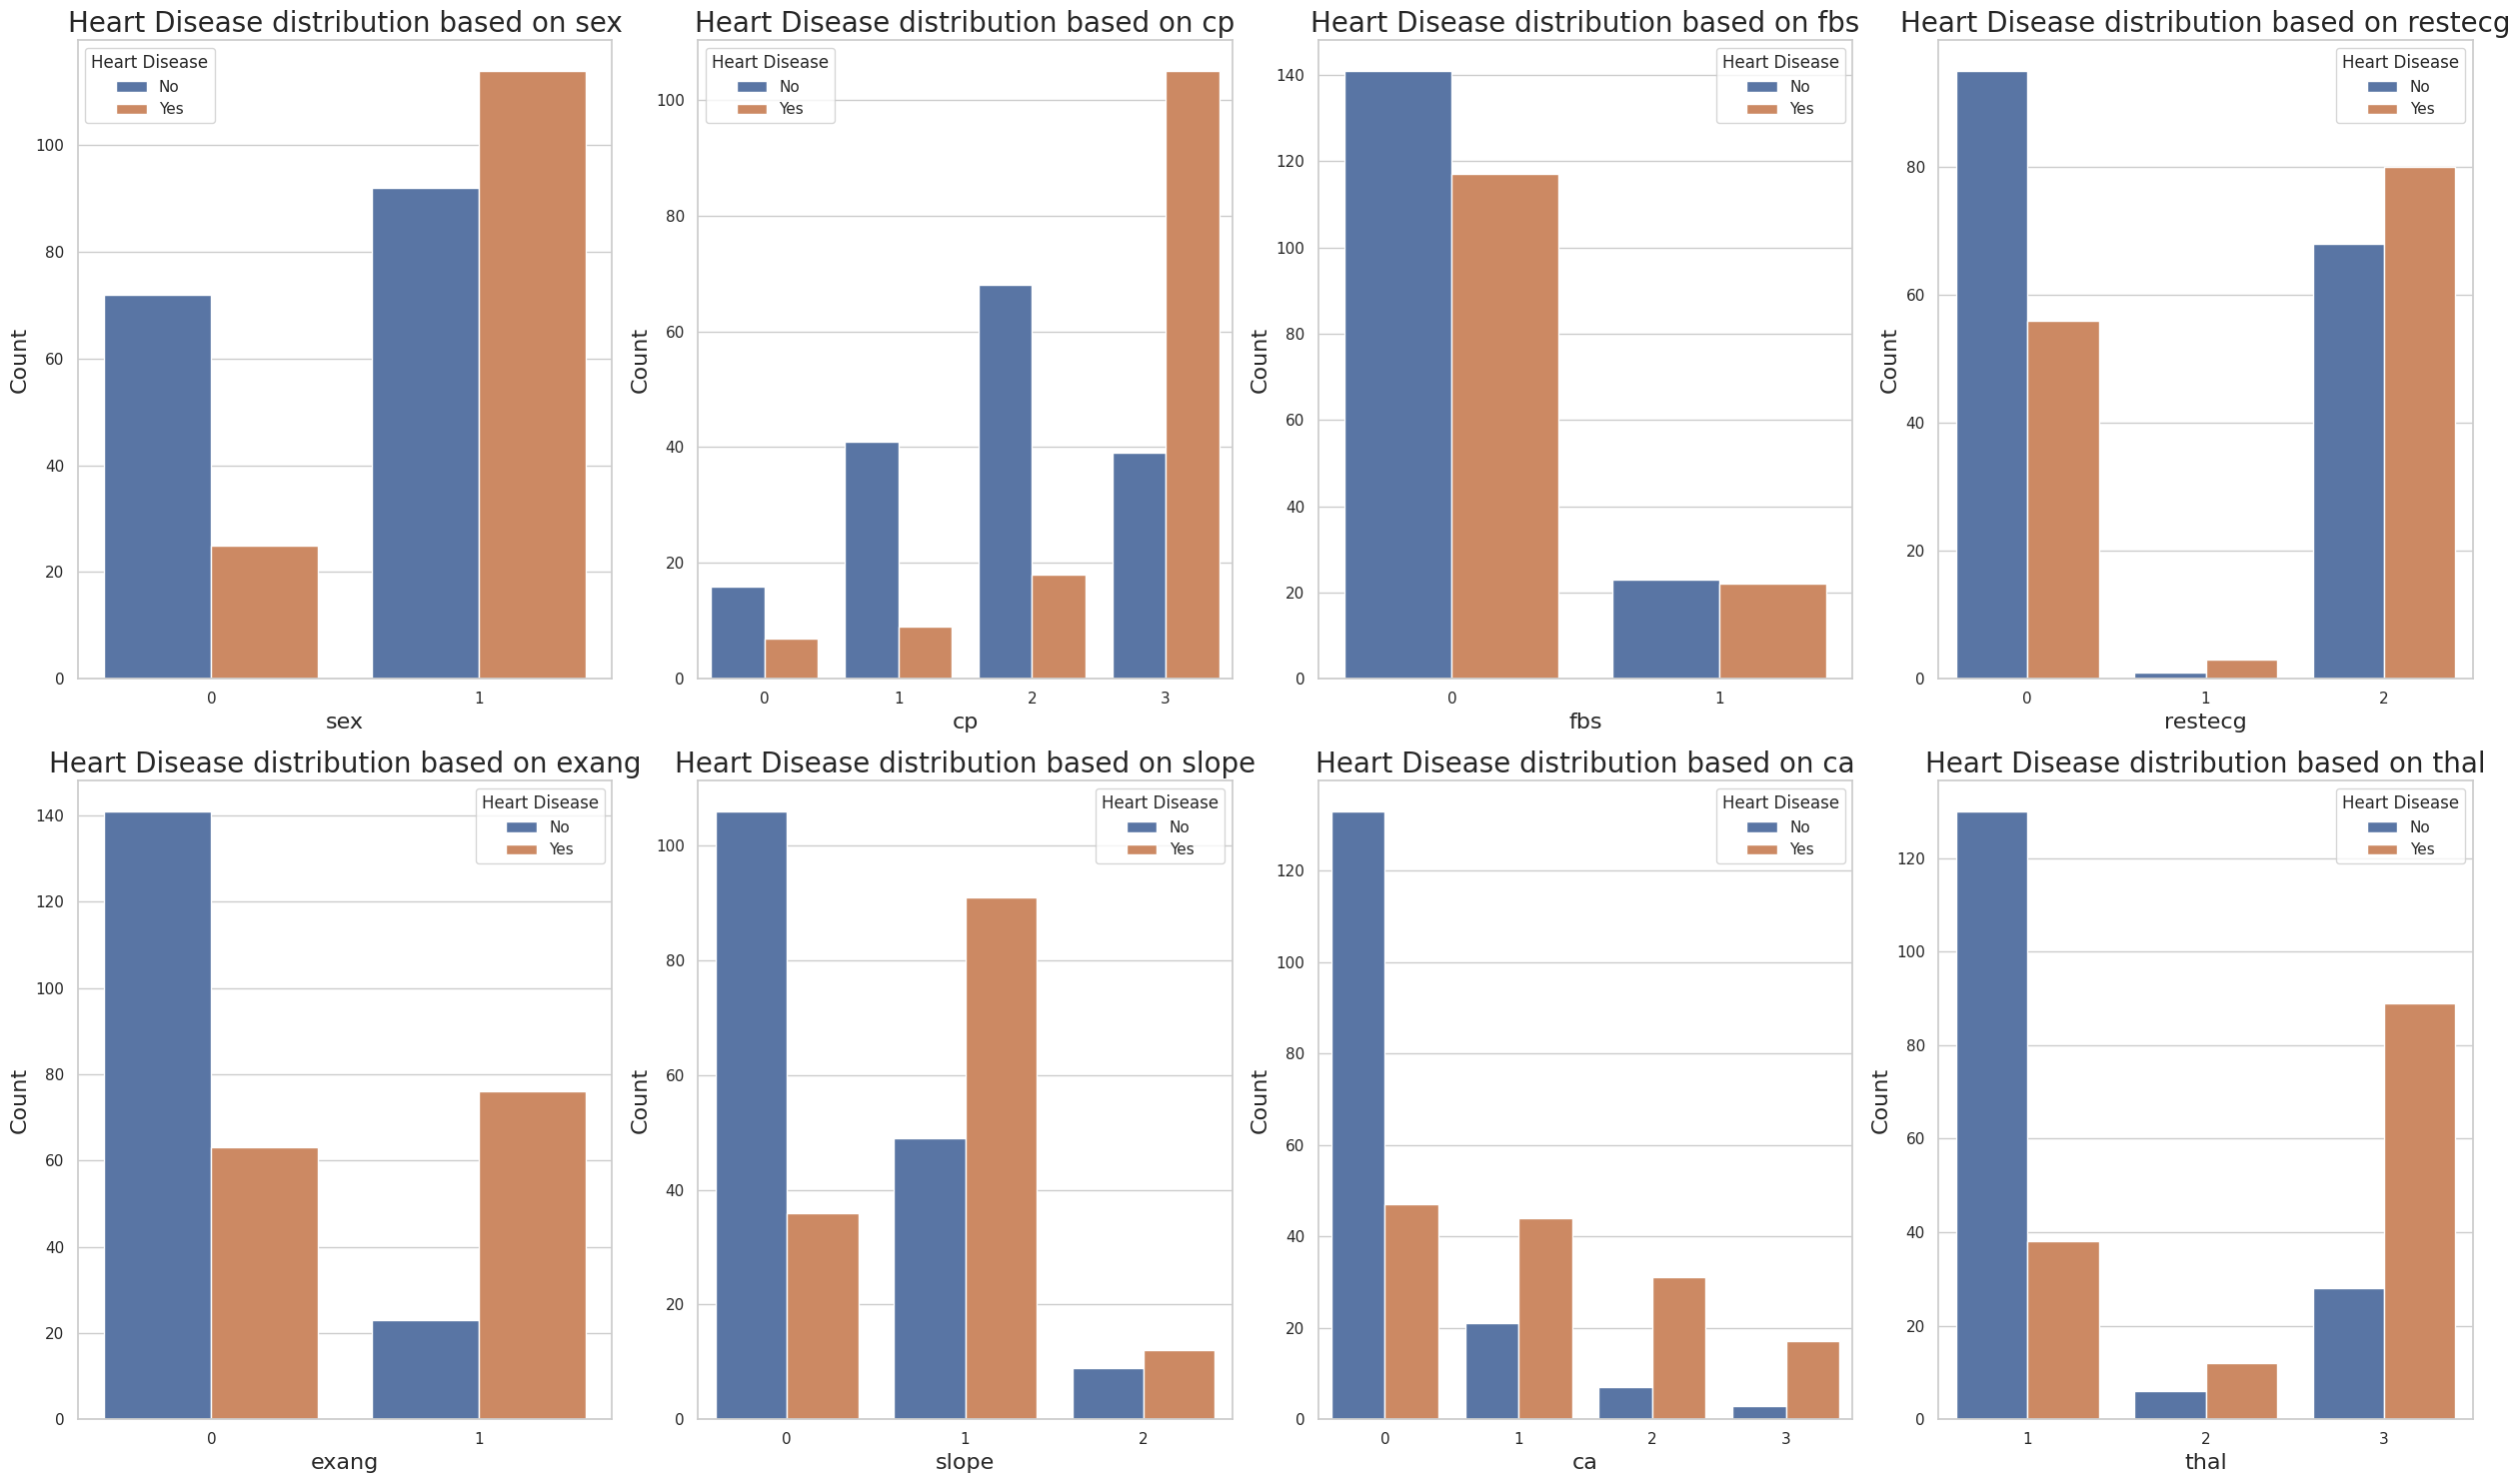

In [28]:
categorical_data= df[['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']]
numerical = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]
plt.figure(figsize=(25, 15))
plotno = 1

for column in categorical_data.columns:
    if plotno <= 8:
        plt.subplot(2, 4, plotno)
        sns.countplot(x=column, hue='target', data=df)
        plt.xlabel(column, fontsize=16)
        plt.ylabel('Count', fontsize=16)
        plt.title(f'Heart Disease distribution based on {column}', fontsize=20)
        plt.legend(title='Heart Disease', labels=['No','Yes'])
        plotno += 1

plt.tight_layout()
plt.show()


Plot shows that heart diseases are more often in females when comparing to male

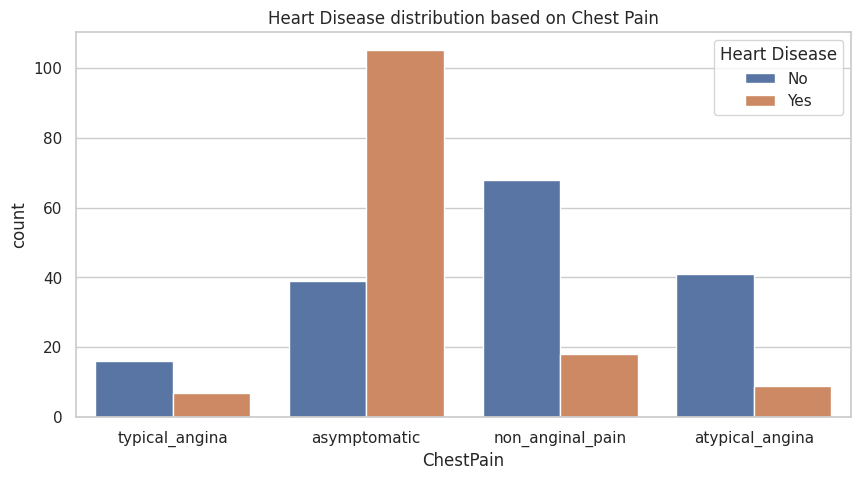

In [18]:
plt.figure(figsize=(10, 5))

cp_mapping = {0: 'typical_angina', 1: 'atypical_angina', 2: 'non_anginal_pain', 3: 'asymptomatic'}
df_mapped['ChestPain'] = df_mapped['cp'].map(cp_mapping)

sns.countplot(x="ChestPain",hue='target', data=df_mapped)
plt.title("Heart Disease distribution based on Chest Pain")
plt.legend(title='Heart Disease', labels=['No','Yes'])
plt.show()

This barplot depicts that the people with asymptomatic chest pain has the higher chances of having a heart disease while comparing with others.


Individuals having Fasting blood pressure is almost similar for male and female.



*   Restecg values 1(Having ST-T wave abnormality) and 2(Showing probable or definite left ventricular hypertrophy) having more heart diseases.
*   Also, female patients having high restecg values.





*   Individuals having Slope 1 and 2 has high rate of heart disease.





*   Heart vessels having colours 2 and 3 appears to have more heart disease rate while comparing with other.


Visualization of numerical data

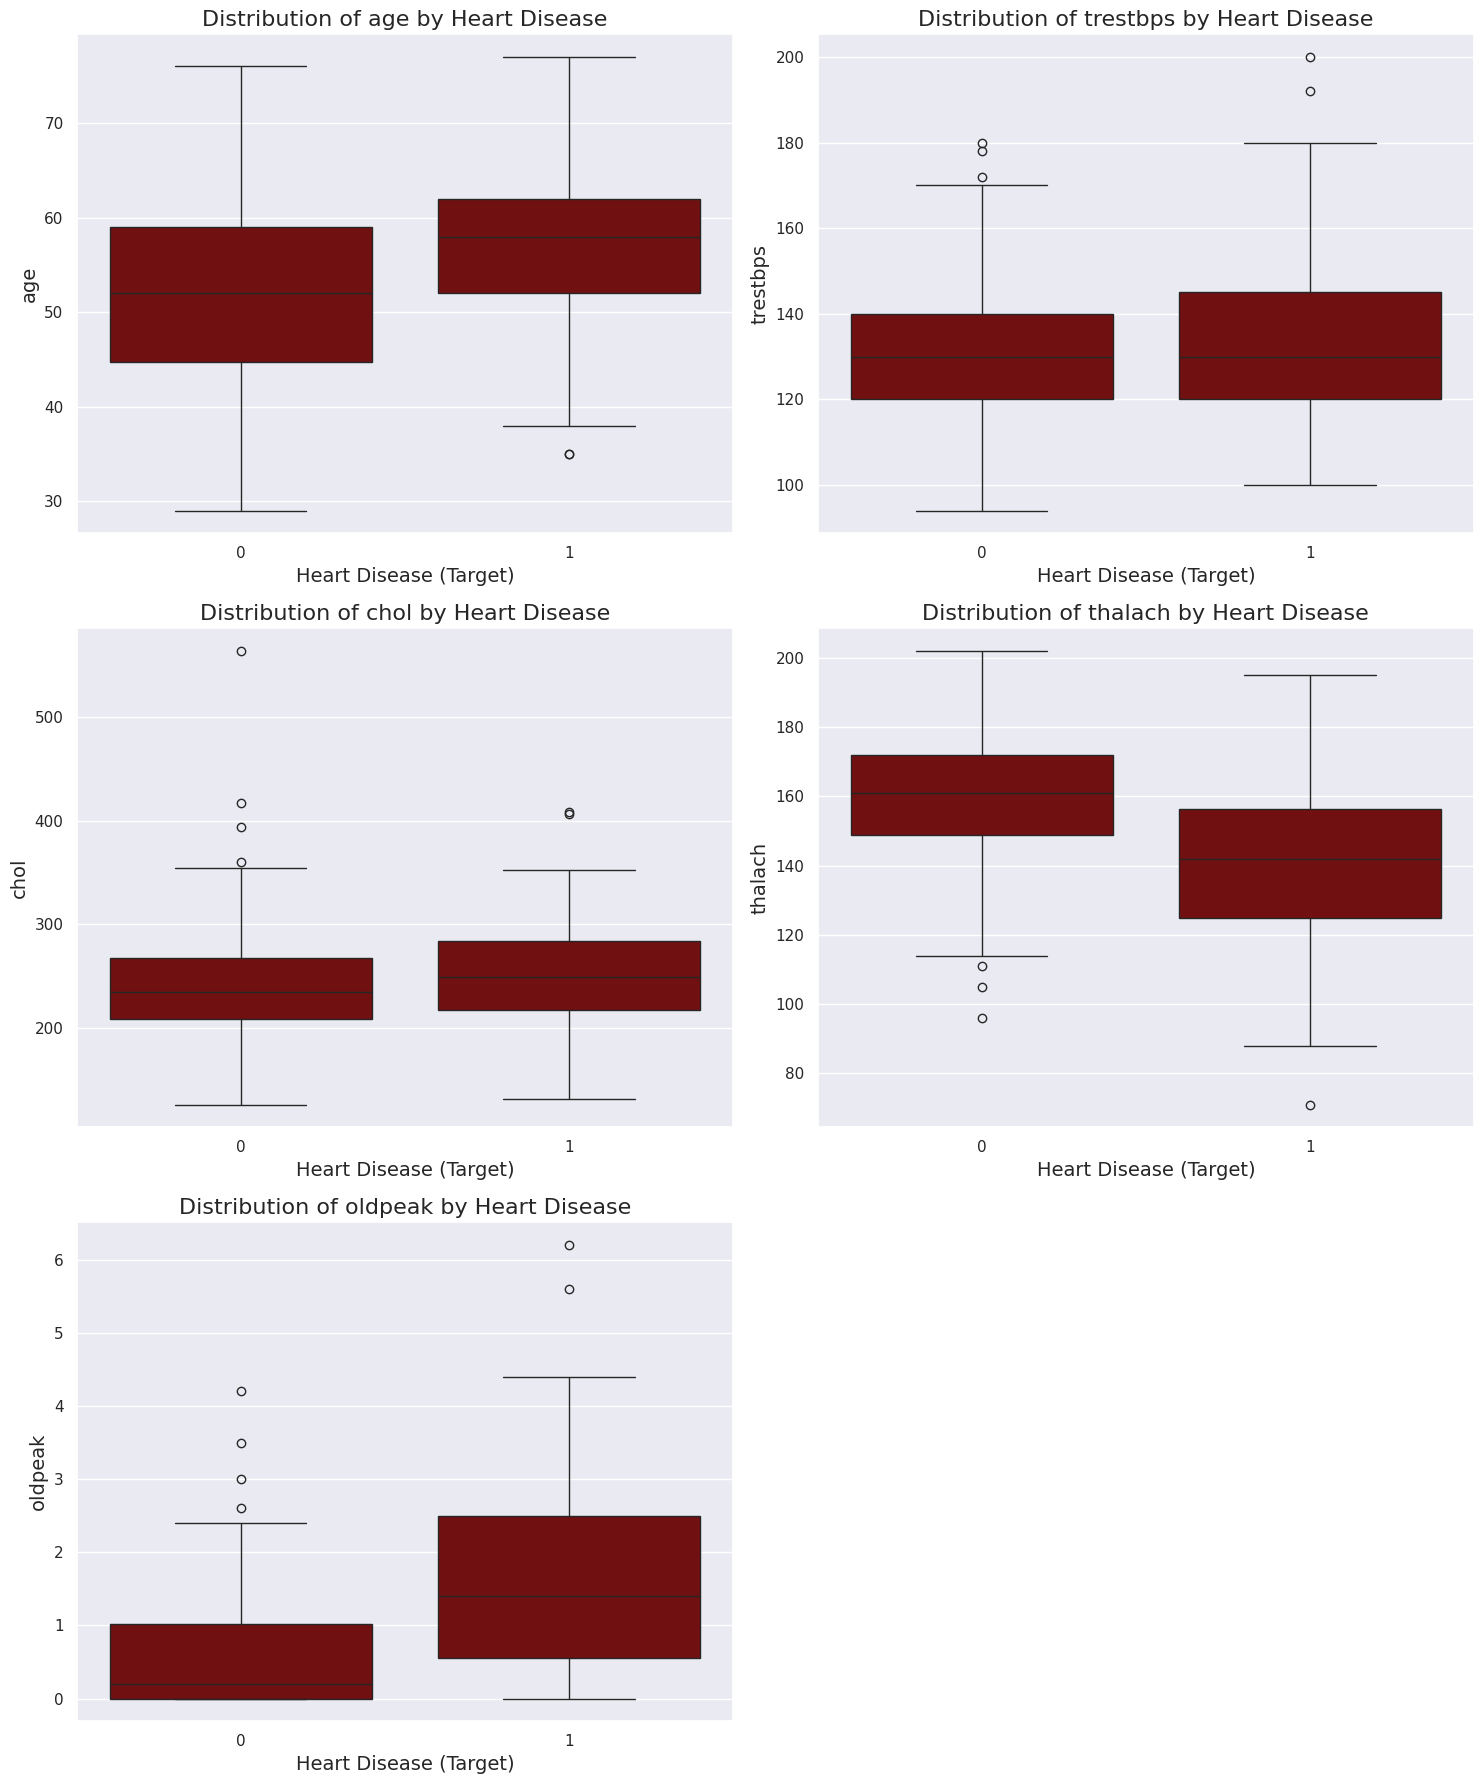

In [41]:
sns.set_style('darkgrid')
plt.figure(figsize=(15, 18))
plotno = 1

for column in numerical.columns:
    if plotno <= 5:
        plt.subplot(3, 2, plotno)

        sns.boxplot(data=df, y=column, x='target', color='maroon')

        plt.ylabel(column, fontsize=14)
        plt.xlabel('Heart Disease (Target)', fontsize=14)
        plt.title(f'Distribution of {column} by Heart Disease', fontsize=16)

        plotno += 1

plt.tight_layout()
plt.show()


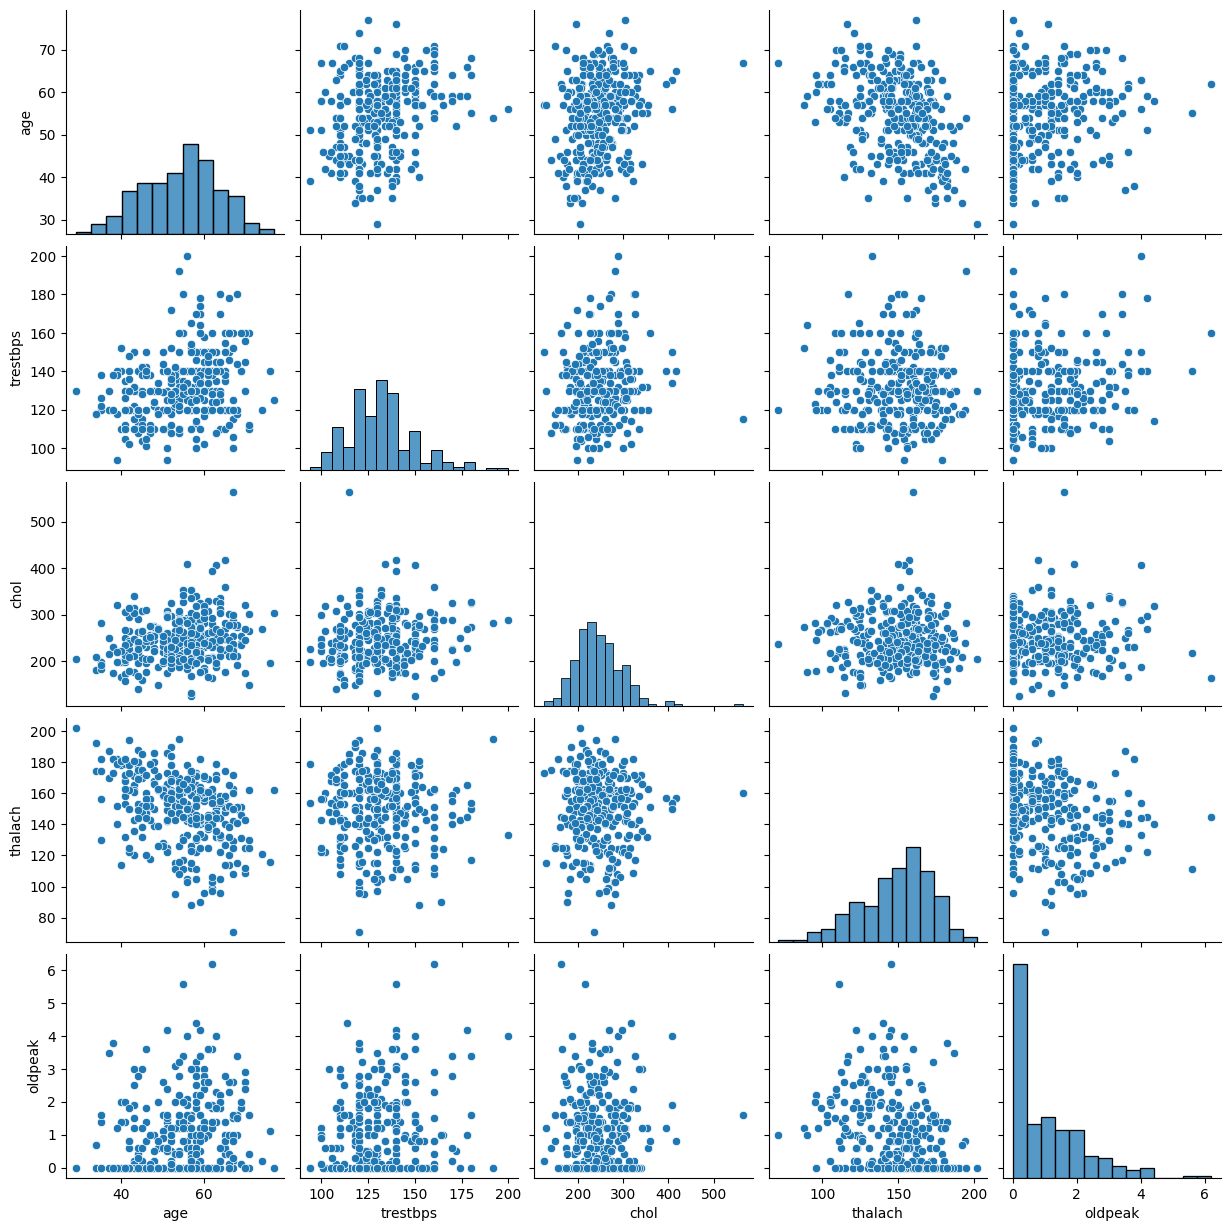

In [6]:
numerical = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]
sns.pairplot(numerical)
plt.show()

# Correlation Heatmap

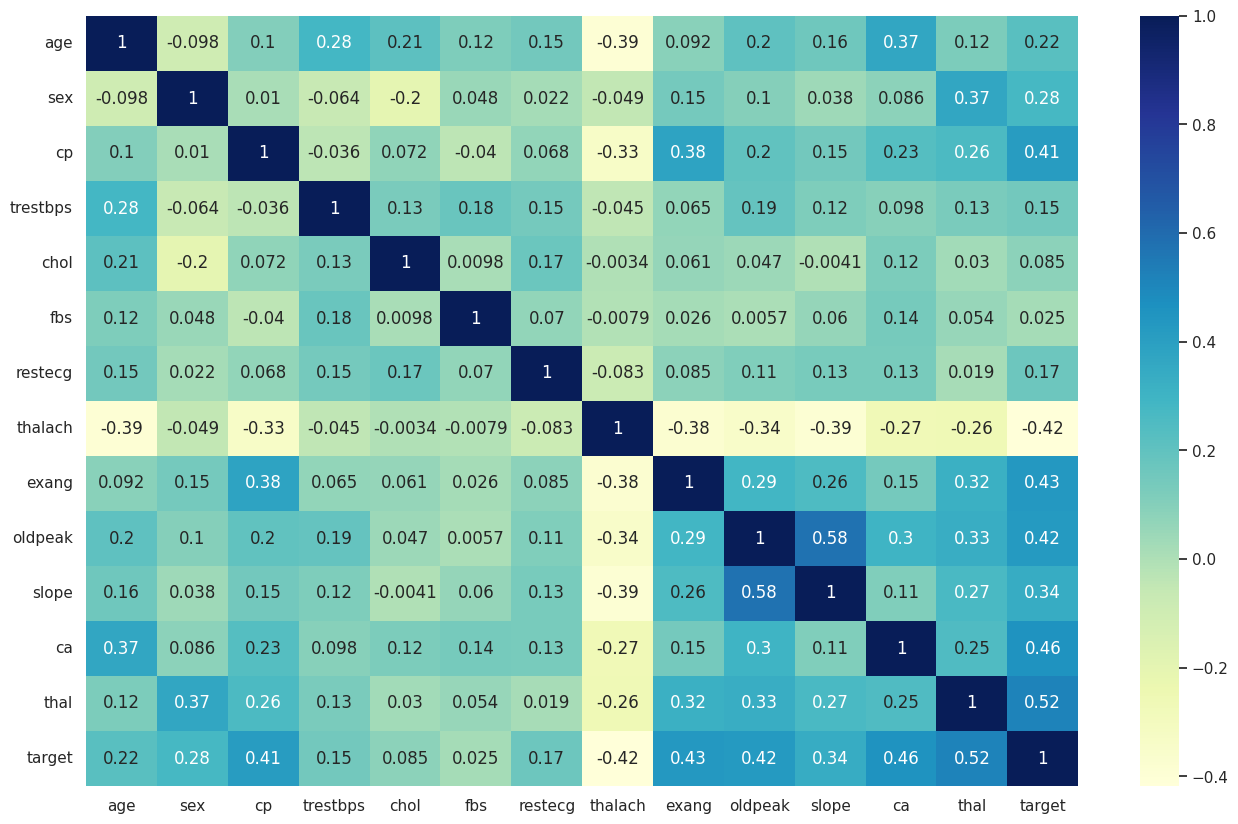

In [42]:
plt.figure(figsize = (16, 10))
sns.heatmap(df.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [3]:
x = df.drop(columns=['target'])
y = df['target']

In [4]:
# We specify this so that the train and test data set always have the same rows, respectively
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify=y)

In [7]:
scaler = StandardScaler()
numeric_scalable_features = numerical.columns
# Fit on training data only and transform training data
X_train[numeric_scalable_features] = scaler.fit_transform(X_train[numeric_scalable_features])

# Transform the test data using the same scaler (do not fit again)
X_test[numeric_scalable_features] = scaler.transform(X_test[numeric_scalable_features])

In [70]:
X_train.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,2.420000e+02,242.000000,242.000000,2.420000e+02,2.420000e+02,242.000000,242.000000,2.420000e+02,242.000000,242.000000,242.000000,242.000000,242.000000
mean,-1.835079e-16,0.681818,2.152893,-3.853667e-16,1.468064e-16,0.144628,0.979339,-7.340318e-18,0.326446,0.000000,0.586777,0.607438,1.830579
std,1.002073e+00,0.466736,0.975516,1.002073e+00,1.002073e+00,0.352454,0.999786,1.002073e+00,0.469885,1.002073,0.613397,0.882534,0.964201
min,-2.845681e+00,0.000000,0.000000,-2.101584e+00,-2.348209e+00,0.000000,0.000000,-3.487829e+00,0.000000,-0.891627,0.000000,0.000000,1.000000
25%,-7.294848e-01,0.000000,1.250000,-6.231442e-01,-7.174932e-01,0.000000,0.000000,-6.830006e-01,0.000000,-0.891627,0.000000,0.000000,1.000000
50%,1.615452e-01,1.000000,2.000000,-5.451337e-02,-1.012342e-01,0.000000,0.000000,1.562396e-01,0.000000,-0.177735,1.000000,0.000000,1.000000
75%,7.184390e-01,1.000000,3.000000,5.141174e-01,5.292462e-01,0.000000,2.000000,7.083712e-01,1.000000,0.536156,1.000000,1.000000,3.000000
max,2.500499e+00,1.000000,3.000000,3.925902e+00,5.957066e+00,1.000000,2.000000,2.298510e+00,1.000000,4.641035,2.000000,3.000000,3.000000


In [71]:
print(X_train.shape, X_test.shape)

(242, 13) (61, 13)


In [8]:
from sklearn.metrics import roc_curve, auc

# Dictionary to store y_test and predicted probabilities for the best-tuned models
best_models_results = {}

def evaluate_model(model, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        best_models_results[model_name] = (y_test, y_pred_proba)  # Store for later ROC plot

    print(f"\n==========================={model_name}=============================")
    print(classification_report(y_test, y_pred))
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=model.classes_)
    disp.plot(cmap="Blues", values_format='')
    plt.grid(False)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    results.append([model_name, report['accuracy'], report['weighted avg']['precision'],
                    report['weighted avg']['recall'], report['weighted avg']['f1-score'], len(y_test)])


In [9]:
models = [
    (LogisticRegression(max_iter=10000, random_state=42), "Logistic Regression"),
    (SVC(kernel='linear', probability=True, random_state=42), "SVM"),
    (RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest"),
    (XGBClassifier(random_state=42), "XGBoost"),
    (GradientBoostingClassifier(random_state=42), "Gradient Boosting")
]


===========================Logistic Regression=============================
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



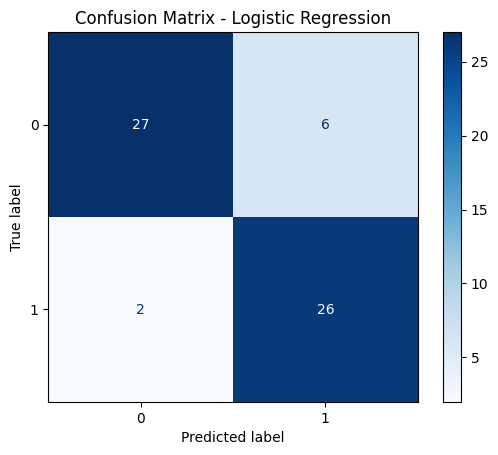


===========================SVM=============================
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



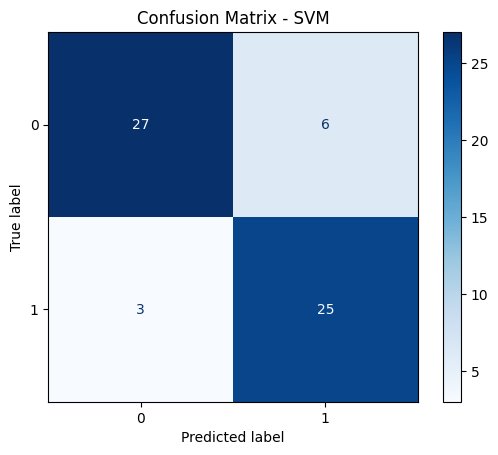


===========================Random Forest=============================
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



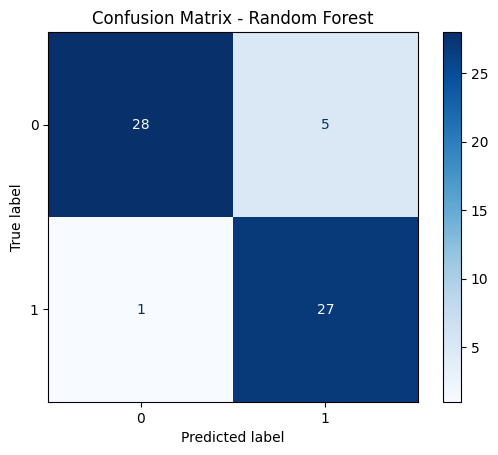


===========================XGBoost=============================
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



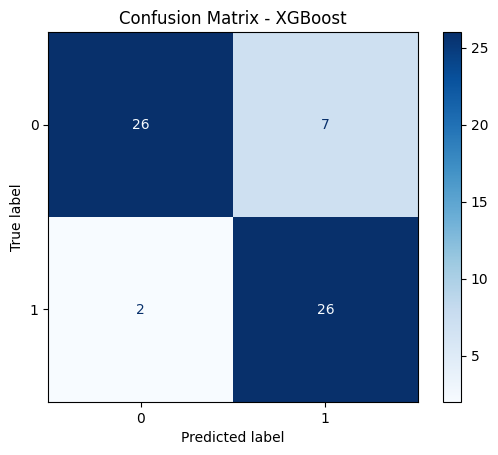


===========================Gradient Boosting=============================
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



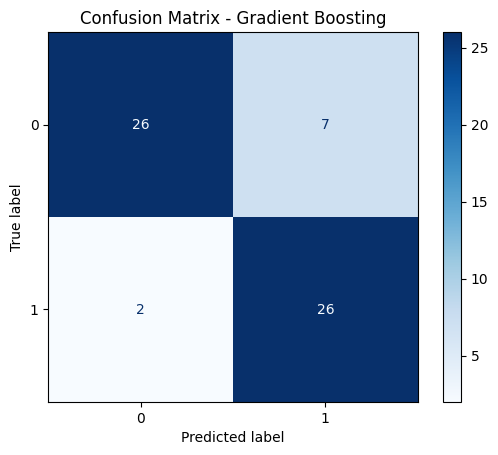

,Model,Accuracy,Precision,Recall,f1-score,Support
0,Logistic Regression,0.868852,0.876625,0.868852,0.868993,61
1,SVM,0.852459,0.857060,0.852459,0.852697,61
2,Random Forest,0.901639,0.909624,0.901639,0.901745,61
3,XGBoost,0.852459,0.863991,0.852459,0.852459,61
4,Gradient Boosting,0.852459,0.863991,0.852459,0.852459,61


In [10]:
results = []
for model, name in models:
    evaluate_model(model, name)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "f1-score", "Support"])
display(results_df)


In [11]:
# Hyperparameter grids for each model
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    }
}

In [78]:
# adjusting version mismatch
!pip install scikit-learn==1.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.3.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.3.0 which is incompatible.




Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters for Logistic Regression: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best model forLogistic Regression:  LogisticRegression(C=0.01, max_iter=10000, random_state=42)

===========================Logistic Regression=============================
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



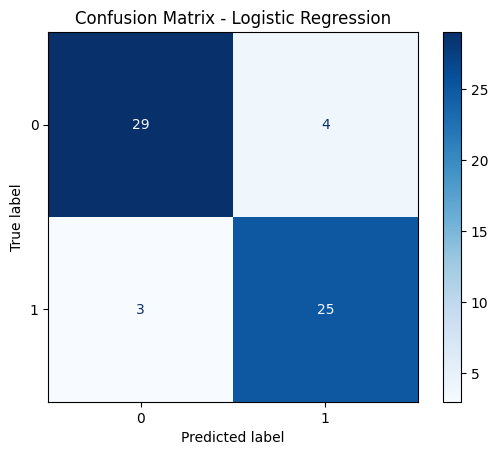



Tuning hyperparameters for SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best model forSVM:  SVC(C=0.1, probability=True, random_state=42)

===========================SVM=============================
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



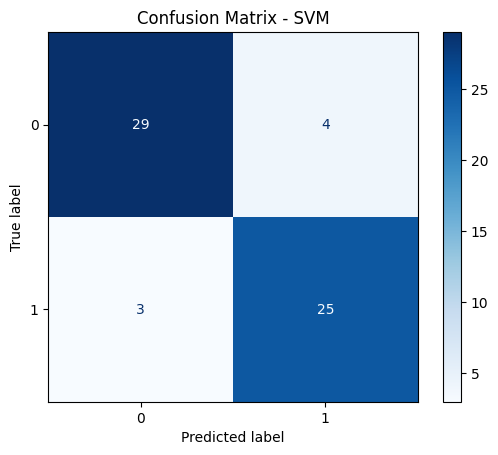



Tuning hyperparameters for Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best model forRandom Forest:  RandomForestClassifier(min_samples_split=5, n_estimators=200, random_state=42)

===========================Random Forest=============================
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



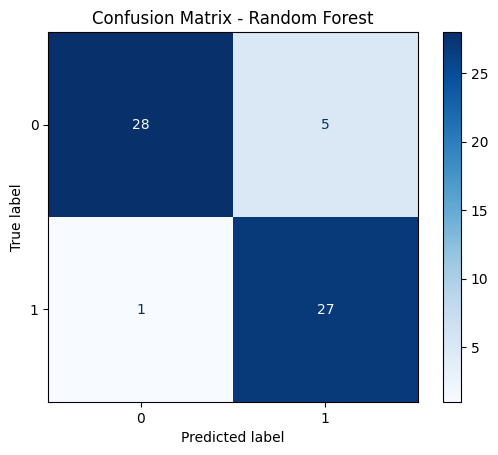



Tuning hyperparameters for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best model forXGBoost:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=

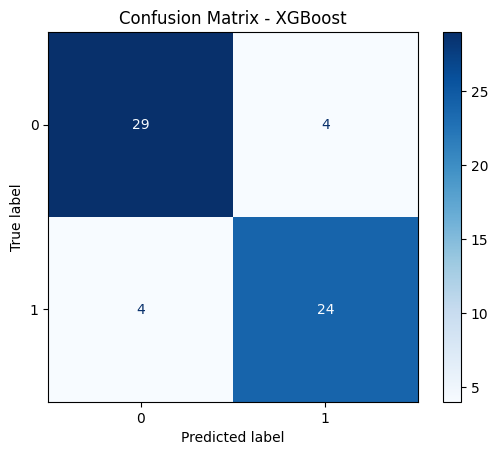



Tuning hyperparameters for Gradient Boosting...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best model forGradient Boosting:  GradientBoostingClassifier(learning_rate=0.01, min_samples_leaf=4,
                           random_state=42)

===========================Gradient Boosting=============================
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        33
           1       0.86      0.86      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



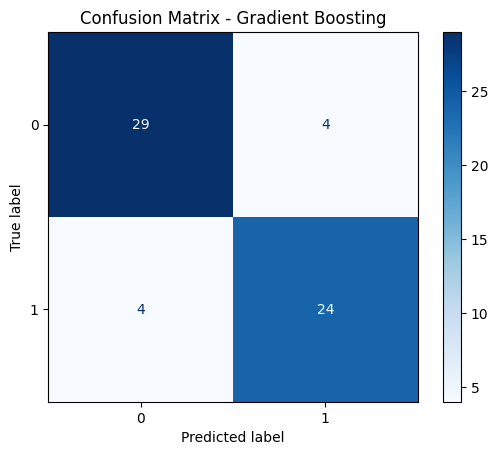

,Model,Accuracy,Precision,Recall,f1-score,Support
0,Logistic Regression,0.868852,0.876625,0.868852,0.868993,61
1,SVM,0.852459,0.857060,0.852459,0.852697,61
2,Random Forest,0.901639,0.909624,0.901639,0.901745,61
3,XGBoost,0.852459,0.863991,0.852459,0.852459,61
4,Gradient Boosting,0.852459,0.863991,0.852459,0.852459,61
5,Logistic Regression,0.885246,0.885970,0.885246,0.885370,61
6,SVM,0.885246,0.885970,0.885246,0.885370,61
7,Random Forest,0.901639,0.909624,0.901639,0.901745,61
8,XGBoost,0.868852,0.868852,0.868852,0.868852,61
9,Gradient Boosting,0.868852,0.868852,0.868852,0.868852,61


In [12]:
from sklearn.model_selection import StratifiedKFold

best_tuned_models = {}
# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model, name in models:
    print(f"\n\nTuning hyperparameters for {name}...")

    param_grid = param_grids.get(name, {})

    if param_grid:
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            cv=cv,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        print(f"Best Parameters for {name}:", grid_search.best_params_)

        # Get the best model
        best_model = grid_search.best_estimator_
        best_tuned_models[name] = grid_search.best_estimator_
        print(f"Best model for{name}: ",best_model)

        evaluate_model(best_model, name)
    else:
        best_tuned_models[name] = model
        evaluate_model(model, name)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "f1-score", "Support"])
display(results_df)

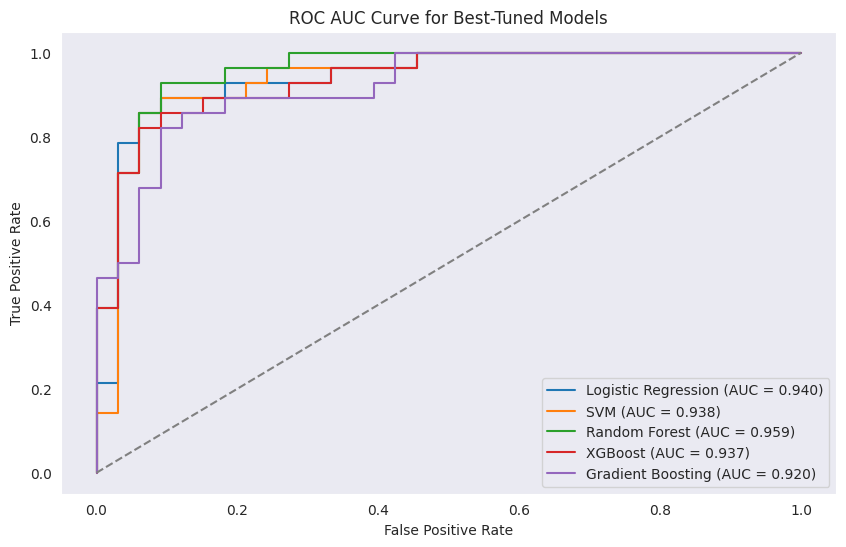

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Plot ROC Curve
plt.figure(figsize=(10, 6))

for model_name, (y_true, y_pred_proba) in best_models_results.items():
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Plot Random Guess (Baseline)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve for Best-Tuned Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()



Best performing model: Random Forest


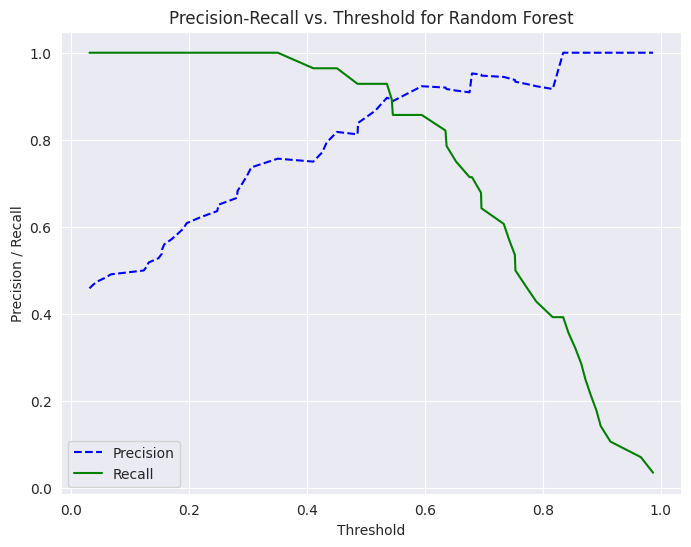

In [ ]:
from sklearn.metrics import precision_recall_curve

# Identify the best model based on highest accuracy
best_model_idx = results_df["Accuracy"].idxmax()
best_model_name = results_df.loc[best_model_idx, "Model"]
print(f"\nBest performing model: {best_model_name}")

# Retrieve the best model
best_model = best_tuned_models[best_model_name]

# Get probabilities for the positive class
y_scores = best_models_results[best_model_name][1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], "b--", label="Precision")
plt.plot(thresholds, recall[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.legend(loc="best")
plt.title(f"Precision-Recall vs. Threshold for {best_model_name}")
plt.grid(True)
plt.show()


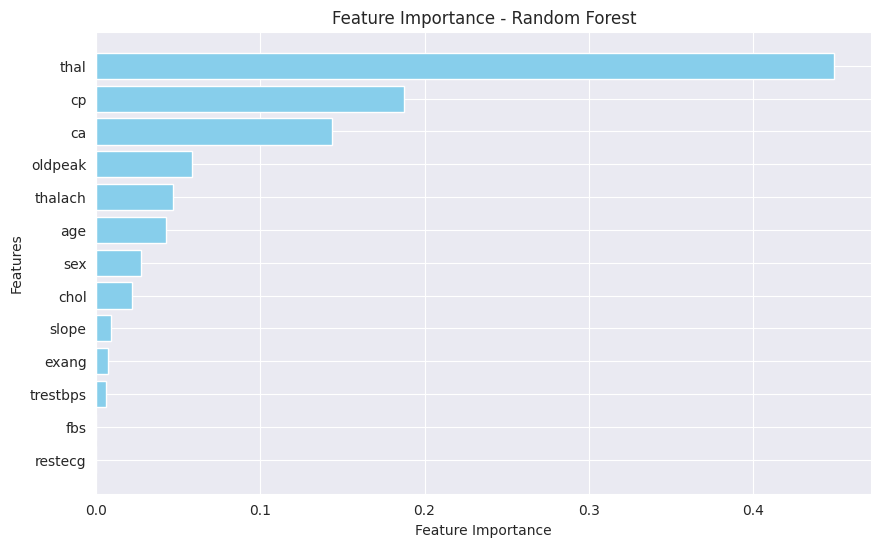


Top Important Features:
    Feature  Importance
12     thal    0.449748
2        cp    0.187274
11       ca    0.143907
9   oldpeak    0.058373
7   thalach    0.046997
0       age    0.042607
1       sex    0.027350
4      chol    0.021492
10    slope    0.008829
8     exang    0.007350


In [ ]:
# Feature Importance for Best Model (Random Forest)
if hasattr(best_model, "feature_importances_"):
    feature_importance = best_model.feature_importances_
    feature_names = X_train.columns

    # Create DataFrame for visualization
    importance_df = pd.DataFrame({"Feature": feature_names, "Importance": feature_importance})
    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.show()

    # Print the top features
    print("\nTop Important Features:")
    print(importance_df.head(10))
